Generated 131 valid assignment pairs (Including Soft Penalty Matches).

✅ Status: OPTIMAL (MILP Solution with Context Switching)
💰 Total Optimized Cost: $815,410.00

--- Snippet of Optimal Assignment Schedule ---


,Task_ID,Employee_ID,Bottleneck_Rho,Work_Hours,Setup_Hours,Total_Billed_Hours,Cost,Req_Dict,Specific_Skills_Dict
0,P001_T1,E013,1.0,80.0,20,100.0,7300.0,{'JUnit': 2},"{'Selenium': 1, 'JUnit': 2}"
1,P001_T2,E005,0.2,1200.0,20,1220.0,97600.0,"{'AWS': 2, 'Kubernetes': 2}","{'Kubernetes': 1, 'Terraform': 2, 'Vue.js': 1}"
2,P002_T1,E025,0.5,320.0,20,340.0,27880.0,{'AWS': 4},"{'Docker': 2, 'AWS': 2}"
3,P002_T2,E025,1.5,67.0,20,87.0,7134.0,{'AWS': 1},"{'Docker': 2, 'AWS': 2}"
4,P002_T3,E007,1.5,80.0,20,100.0,8500.0,"{'Vue.js': 1, 'TypeScript': 1}","{'Vue.js': 2, 'TypeScript': 2, 'AWS': 1}"
5,P003_T1,E023,1.0,40.0,20,60.0,4020.0,{'Angular': 1},"{'Angular': 1, 'TypeScript': 1}"
6,P003_T2,E014,1.5,80.0,20,100.0,19800.0,{'SQL': 1},"{'SQL': 5, 'Spark': 5, 'Pandas': 5, 'Selenium'..."
7,P004_T1,E013,0.2,400.0,20,420.0,30660.0,"{'JUnit': 1, 'PyTest': 1}","{'Selenium': 1, 'JUnit': 2}"
8,P004_T2,E006,1.0,240.0,20,260.0,24180.0,"{'Go': 2, 'Java': 1}","{'Go': 2, 'Java': 2, 'AWS': 1}"
9,P004_T3,E004,0.2,1500.0,20,1520.0,118560.0,"{'Node.js': 3, 'Go': 1}","{'Go': 1, 'C#': 3}"



--- Task Fragmentation Check (Should be much lower now!) ---


,Task_ID,Employees_Assigned
0,P001_T1,1
1,P001_T2,1
2,P002_T1,1
3,P002_T2,1
4,P002_T3,1
5,P003_T1,1
6,P003_T2,1
7,P004_T1,1
8,P004_T2,1
9,P004_T3,1



📊 Saved Chart 1 (False Economy) to: 2026-04-22_17-04-38/false_economy_chart.png


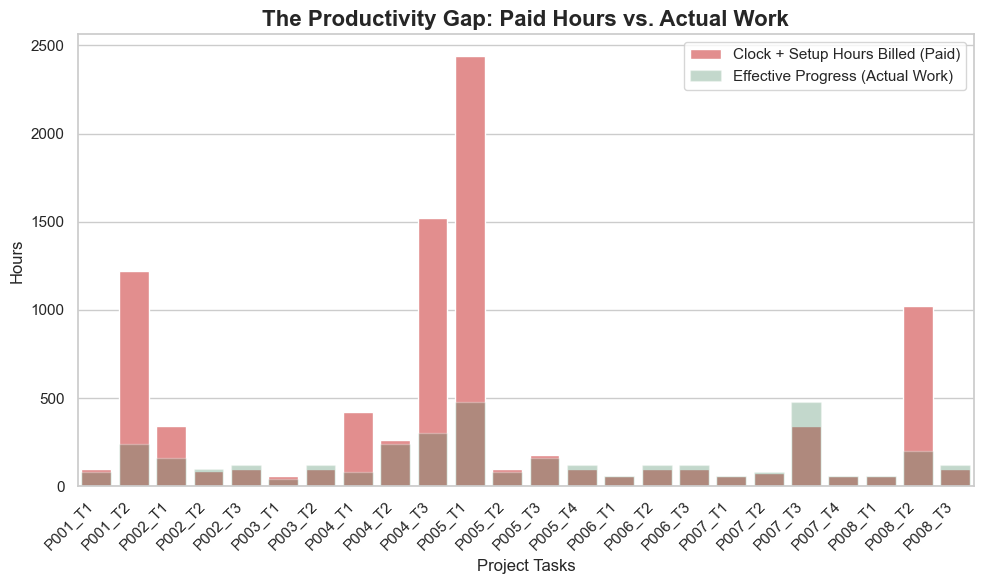

📊 Saved Chart 2 (Cost Distribution) to: 2026-04-22_17-04-38/cost_distribution_chart.png


/var/folders/rv/jrnyg0dj6610p3b7wcp05hg40000gn/T/ipykernel_71437/3915644924.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=cost_summary[:15], x='Employee_ID', y='Cost', palette='viridis')


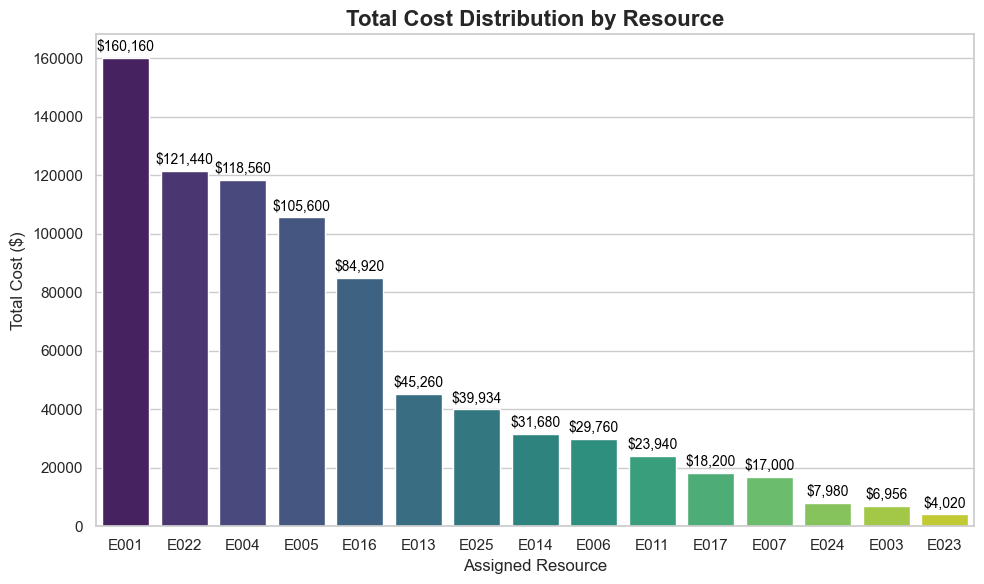

In [4]:
import pandas as pd
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD AND PREP DATA
# ==========================================
EXPORT_PATH = '2026-04-22_17-04-38' # UPDATE THIS IF NEEDED

try:
    employees_df = pd.read_csv(f'{EXPORT_PATH}/employees.csv')
    tasks_df = pd.read_csv(f'{EXPORT_PATH}/tasks.csv')
except FileNotFoundError:
    print("Error: Could not find the CSVs.")
    raise

# Custom Parser for "Skill:Level|Skill:Level" format
def parse_skill_string(skill_str):
    if pd.isna(skill_str) or not isinstance(skill_str, str):
        return {}
    skill_dict = {}
    for item in skill_str.split('|'):
        if ':' in item:
            skill, level = item.split(':')
            skill_dict[skill.strip()] = int(level.strip())
    return skill_dict

employees_df['Specific_Skills_Dict'] = employees_df['Specific_Skills'].apply(parse_skill_string)
tasks_df['Req_Dict'] = tasks_df['Skills_Needed'].apply(parse_skill_string) 

# Safety check for EXT_CONTRACTOR
if 'EXT_CONTRACTOR' not in employees_df['Employee_ID'].values:
    all_required_skills = set()
    for req_dict in tasks_df['Req_Dict']:
        all_required_skills.update(req_dict.keys())

    contractor_skills = {skill: 5 for skill in all_required_skills}

    contractor = pd.DataFrame([{
        'Employee_ID': 'EXT_CONTRACTOR',
        'Specific_Skills_Dict': contractor_skills,
        'Hourly_Cost': 5000,
        'Max_Hours': 999999
    }])
    employees_df = pd.concat([employees_df, contractor], ignore_index=True)


# ==========================================
# 2. VALID PAIRS & THE BOTTLENECK PRINCIPLE (SOFT CONSTRAINTS)
# ==========================================
def calculate_skill_rho(emp_level, task_level):
    if emp_level == 0:
        return 0.2  # MISSING SKILL PENALTY: Takes 5x as long
    elif emp_level == task_level:
        return 1.0  # Perfect match
    elif emp_level > task_level:
        return 1.5  # Over-qualified
    else:
        return 0.5  # Under-qualified

valid_pairs = []
rho_dict = {} 

for _, emp in employees_df.iterrows():
    emp_skills = emp['Specific_Skills_Dict']
    
    for _, task in tasks_df.iterrows():
        task_reqs = task['Req_Dict']
        
        skill_rhos = []
        missing_skills_count = 0
        
        for skill, req_level in task_reqs.items():
            emp_level = emp_skills.get(skill, 0) # Default to 0 if missing
            
            if emp_level == 0:
                missing_skills_count += 1
                
            skill_rhos.append(calculate_skill_rho(emp_level, req_level))
        
        # LOGICAL RULE: Employee must possess AT LEAST ONE of the required skills
        if missing_skills_count < len(task_reqs):
            overall_rho = min(skill_rhos)
            pair = (emp['Employee_ID'], task['Task_ID'])
            valid_pairs.append(pair)
            rho_dict[pair] = overall_rho

print(f"Generated {len(valid_pairs)} valid assignment pairs (Including Soft Penalty Matches).")


# ==========================================
# 3. BUILD THE MILP SOLVER (CONTEXT SWITCHING BIG-M METHOD)
# ==========================================
solver = pywraplp.Solver.CreateSolver('SCIP')

# A. Decision Variables
x = {} # Integer: Physical clock hours worked
y = {} # Binary: 1 if assigned to the task, 0 if not

M = 2080          # Big-M (Maximum possible hours an employee can work)
TAU_PENALTY = 20  # The Context Switch Penalty (20 hours lost per new task)

for (i, j) in valid_pairs:
    x[(i, j)] = solver.IntVar(0, solver.infinity(), f'x_{i}_{j}')
    y[(i, j)] = solver.BoolVar(f'y_{i}_{j}') 

# B. Objective Function (Minimize Cost: Wages for Work + Wages for Setup Time)
cost_dict = employees_df.set_index('Employee_ID')['Hourly_Cost'].to_dict()
objective = solver.Objective()
for (i, j) in valid_pairs:
    wage = float(cost_dict[i])
    objective.SetCoefficient(x[(i, j)], wage)
    objective.SetCoefficient(y[(i, j)], wage * TAU_PENALTY)
objective.SetMinimization()

# C. Constraint 1: Big-M Linking (If x > 0, y MUST be 1)
# x_ij - M * y_ij <= 0
for (i, j) in valid_pairs:
    constraint = solver.Constraint(-solver.infinity(), 0, f"BigM_{i}_{j}")
    constraint.SetCoefficient(x[(i, j)], 1)
    constraint.SetCoefficient(y[(i, j)], -M)

# D. Constraint 2: Demand Satisfaction (With Bottleneck Rho)
demand_dict = tasks_df.set_index('Task_ID')['Hours_Needed'].to_dict()
for j in tasks_df['Task_ID']:
    capable_employees = [i for (i, t_id) in valid_pairs if t_id == j]
    constraint = solver.Constraint(float(demand_dict[j]), solver.infinity(), f"Demand_{j}")
    for i in capable_employees:
        rho = rho_dict[(i, j)]
        constraint.SetCoefficient(x[(i, j)], float(rho))

# E. Constraint 3: Integer Capacity Limit (Work + Setup Time)
cap_dict = employees_df.set_index('Employee_ID')['Max_Hours'].to_dict()
for i in employees_df['Employee_ID']:
    assigned_tasks = [j for (e_id, j) in valid_pairs if e_id == i]
    constraint = solver.Constraint(0, float(cap_dict[i]), f"Capacity_{i}")
    for j in assigned_tasks:
        constraint.SetCoefficient(x[(i, j)], 1)             # Actual work hours
        constraint.SetCoefficient(y[(i, j)], TAU_PENALTY)   # Setup penalty tax


# ==========================================
# 4. SOLVE & EXTRACT
# ==========================================
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print(f"\n✅ Status: OPTIMAL (MILP Solution with Context Switching)")
    print(f"💰 Total Optimized Cost: ${solver.Objective().Value():,.2f}")
    
    results = []
    for (i, j) in valid_pairs:
        assigned_clock_hours = x[(i, j)].solution_value()
        is_assigned = y[(i, j)].solution_value()
        
        if is_assigned > 0.5: # 0.5 is a safe threshold for a Binary 1
            rho = rho_dict[(i, j)]
            paid_setup_hours = TAU_PENALTY
            total_billed_hours = assigned_clock_hours + paid_setup_hours
            
            results.append({
                'Task_ID': j,
                'Employee_ID': i,
                'Bottleneck_Rho': rho,
                'Work_Hours': assigned_clock_hours,
                'Setup_Hours': paid_setup_hours,
                'Total_Billed_Hours': total_billed_hours,
                'Effective_Progress': assigned_clock_hours * rho, # Setup time yields 0 progress
                'Cost': total_billed_hours * cost_dict[i]
            })
            
    results_df = pd.DataFrame(results).sort_values(by=['Task_ID', 'Employee_ID']).reset_index(drop=True)
    
    # Merge for display clarity
    display_df = results_df.merge(tasks_df[['Task_ID', 'Req_Dict']], on='Task_ID')
    display_df = display_df.merge(employees_df[['Employee_ID', 'Specific_Skills_Dict']], on='Employee_ID')
    
    print("\n--- Snippet of Optimal Assignment Schedule ---")
    display(display_df[['Task_ID', 'Employee_ID', 'Bottleneck_Rho', 'Work_Hours', 'Setup_Hours', 'Total_Billed_Hours', 'Cost', 'Req_Dict', 'Specific_Skills_Dict']].head(15))
    
    # Prove the consolidation to your audience:
    frag_check = results_df.groupby('Task_ID')['Employee_ID'].count().reset_index()
    frag_check.columns = ['Task_ID', 'Employees_Assigned']
    print("\n--- Task Fragmentation Check (Should be much lower now!) ---")
    display(frag_check.head(10))
    
    # Contractor check
    contractor_hrs = results_df[results_df['Employee_ID'] == 'EXT_CONTRACTOR']['Total_Billed_Hours'].sum()
    if contractor_hrs > 0:
        print(f"\n🚨 ALERT: Outsourced {contractor_hrs:,.0f} hours to EXT_CONTRACTOR due to skill/capacity shortages.")
else:
    print("Solver failed. Status:", status)

# ==========================================
# 5. VISUALIZATION
# ==========================================
sns.set_theme(style="whitegrid")

task_summary = display_df.groupby('Task_ID')[['Total_Billed_Hours', 'Effective_Progress']].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=task_summary[:30], x='Task_ID', y='Total_Billed_Hours', color='lightcoral', label='Clock + Setup Hours Billed (Paid)')
sns.barplot(data=task_summary[:30], x='Task_ID', y='Effective_Progress', color='seagreen', label='Effective Progress (Actual Work)', alpha = 0.3)

plt.title('The Productivity Gap: Paid Hours vs. Actual Work', fontsize=16, fontweight='bold')
plt.xlabel('Project Tasks', fontsize=12)
plt.ylabel('Hours', fontsize=12)
plt.legend(loc='upper right')
plt.xticks(rotation=45, ha='right') # Added rotation so task names don't overlap
plt.tight_layout()

chart1_path = f"{EXPORT_PATH}/false_economy_chart.png"
plt.savefig(chart1_path, dpi=300)
print(f"\n📊 Saved Chart 1 (False Economy) to: {chart1_path}")
plt.show()

cost_summary = display_df.groupby('Employee_ID')['Cost'].sum().reset_index()
cost_summary = cost_summary.sort_values('Cost', ascending=False)

plt.figure(figsize=(10, 6))
bars = sns.barplot(data=cost_summary[:15], x='Employee_ID', y='Cost', palette='viridis')

for i, bar in enumerate(bars.patches):
    if cost_summary.iloc[i]['Employee_ID'] == 'EXT_CONTRACTOR':
        bar.set_color('firebrick')

plt.title('Total Cost Distribution by Resource', fontsize=16, fontweight='bold')
plt.xlabel('Assigned Resource', fontsize=12)
plt.ylabel('Total Cost ($)', fontsize=12)

for p in bars.patches:
    bars.annotate(f'${p.get_height():,.0f}', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), 
                  textcoords='offset points')

plt.tight_layout()

chart2_path = f"{EXPORT_PATH}/cost_distribution_chart.png"
plt.savefig(chart2_path, dpi=300)
print(f"📊 Saved Chart 2 (Cost Distribution) to: {chart2_path}")
plt.show()